# Exploracija podatkov po postajah in letih
Pregled koliko dnevnih meritev ima vsaka ARSO postaja, razčlenjeno po letih.

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Poišči ROOT
_search = Path(os.getcwd()).resolve()
ROOT = None
for _ in range(5):
    if (_search / "src").exists() and (_search / "data").exists():
        ROOT = _search
        break
    _search = _search.parent
if ROOT is None:
    ROOT = Path("/home/anejm/Documents/hekaton/BarkWatch-arnes_hackathon2026")

VREME_PATH   = ROOT / "data" / "raw" / "ARSO" / "vreme.csv"
LOKACIJE_PATH = ROOT / "data" / "raw" / "ARSO" / "lokacije.csv"
print(f"ROOT: {ROOT}")

ROOT: /home/anejm/Documents/hekaton/BarkWatch-arnes_hackathon2026


## 1. Naloži podatke

In [3]:
df = pd.read_csv(VREME_PATH, dtype={"station_id": str})
df["datum"] = pd.to_datetime(df["datum"], errors="coerce")
df = df.dropna(subset=["datum"])
df["leto"] = df["datum"].dt.year

lokacije = pd.read_csv(LOKACIJE_PATH, dtype={"ID": str})
lokacije = lokacije.rename(columns={"ID": "station_id", "Name": "ime", "Type": "tip"})

print(f"Vrstic: {len(df):,}")
print(f"Postaj: {df['station_id'].nunique()}")
print(f"Obdobje: {df['datum'].min().date()} – {df['datum'].max().date()}")
print(f"\nStolpci: {list(df.columns)}")

Vrstic: 1,556,514
Postaj: 217
Obdobje: 1800-01-01 – 2026-03-20

Stolpci: ['station_id', 'datum', 'povp_dnevna_T_ÂdegC', 'max_T_ÂdegC', 'min_T_ÂdegC', 'koliÄ\x8dina_padavin_mm', 'viÅ¡ina_sneÅ¾ne_odeje_cm', 'viÅ¡ina_novega_snega_cm', 'nevihta', 'toÄ\x8da', 'viharni_veter', 'leto']


## 2. Število meritev po postaji in letu

In [4]:
# Pivot: vrstice = postaje, stolpci = leta, vrednosti = št. dni
pivot = (
    df.groupby(["station_id", "leto"])
    .size()
    .rename("n_dni")
    .reset_index()
    .pivot(index="station_id", columns="leto", values="n_dni")
    .sort_index()
)

# Dodaj ime postaje
pivot = pivot.join(lokacije.set_index("station_id")[["ime", "tip"]], how="left")
pivot.insert(0, "ime", pivot.pop("ime"))
pivot.insert(1, "tip", pivot.pop("tip"))

print(f"Postaje: {len(pivot)}  |  Leta: {df['leto'].min()} – {df['leto'].max()}")
pivot

Postaje: 217  |  Leta: 1800 – 2026


,ime,tip,1800,2000,2001,2002,2003,2004,2005,2006,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
station_id,,,,,,,,,,,,,,,,,,,,,
1611,Planina - Hasberg,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,61.0,365.0,365.0,365.0,59.0
1612,NaN,NaN,9.0,365.0,365.0,364.0,365.0,365.0,365.0,365.0,...,364.0,365.0,364.0,366.0,90.0,NaN,NaN,NaN,NaN,NaN
1613,Kamniška Bistrica,1.0,11.0,365.0,365.0,364.0,365.0,365.0,365.0,335.0,...,364.0,365.0,364.0,366.0,365.0,364.0,365.0,365.0,365.0,59.0
1614,NaN,NaN,11.0,365.0,365.0,364.0,365.0,365.0,365.0,365.0,...,364.0,365.0,364.0,366.0,365.0,364.0,365.0,365.0,365.0,79.0
1622,Poljane nad Škofjo Loko,1.0,11.0,365.0,365.0,364.0,365.0,365.0,365.0,365.0,...,364.0,365.0,364.0,366.0,365.0,364.0,365.0,365.0,365.0,59.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4759,Hrib - Loški Potok,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,365.0,365.0,59.0
4760,Trava,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,365.0,365.0,59.0
4762,Podgorje (Apače),1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,334.0,365.0,59.0


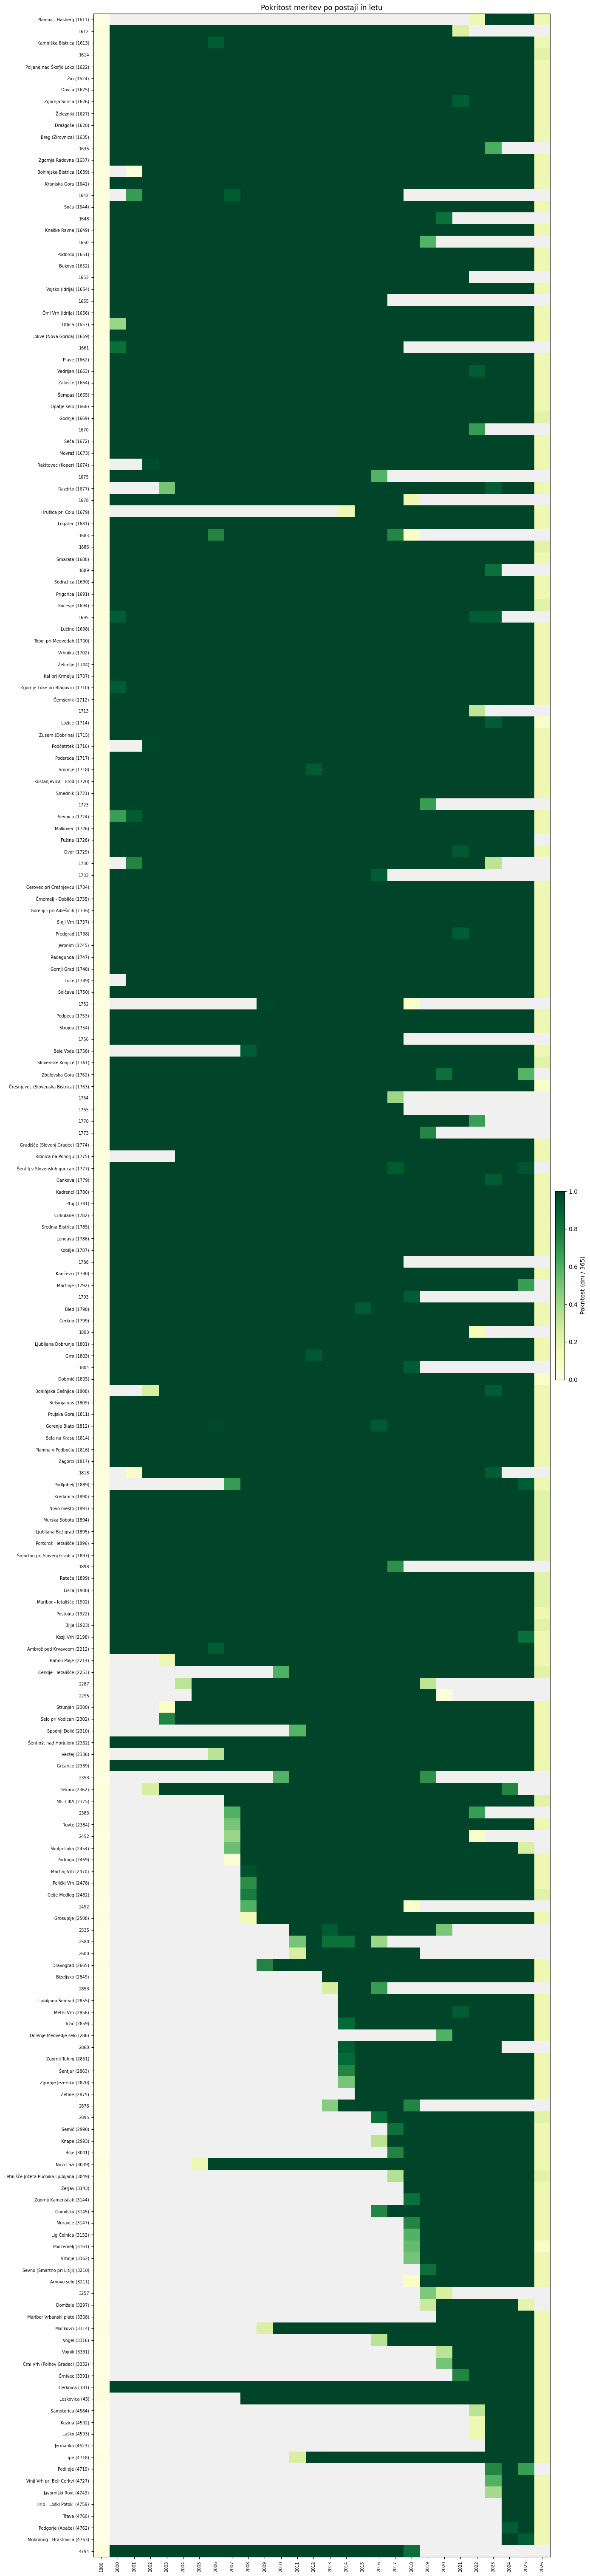

In [5]:
# Samo numerični stolpci (leta)
leta_cols = [c for c in pivot.columns if isinstance(c, (int, np.integer))]
mat = pivot[leta_cols].values.astype(float)

# Normaliziramo: 0 = ni podatkov, 1 = 365+ dni
mat_norm = np.clip(mat / 365, 0, 1)

fig, ax = plt.subplots(figsize=(max(14, len(leta_cols) * 0.35), max(6, len(pivot) * 0.28)))

cmap = plt.cm.YlGn
cmap.set_bad(color="#f0f0f0")  # NaN = svetlo siva

im = ax.imshow(np.ma.masked_invalid(mat_norm), aspect="auto", cmap=cmap, vmin=0, vmax=1)

ax.set_xticks(range(len(leta_cols)))
ax.set_xticklabels(leta_cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(
    [f"{row['ime']} ({idx})" if pd.notna(row["ime"]) else idx
     for idx, row in pivot[["ime"]].iterrows()],
    fontsize=7
)

cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label("Pokritost (dni / 365)")
ax.set_title("Pokritost meritev po postaji in letu", fontsize=12)
plt.tight_layout()
plt.show()

# Samo numerični stolpci (leta), filtrirano od 2007 naprej
leta_cols = [c for c in pivot.columns if isinstance(c, (int, np.integer)) and c >= 2007]
mat = pivot[leta_cols].values.astype(float)

# Normaliziramo: 0 = ni podatkov, 1 = 365+ dni
mat_norm = np.clip(mat / 365, 0, 1)

fig, ax = plt.subplots(figsize=(max(14, len(leta_cols) * 0.35), max(6, len(pivot) * 0.28)))

cmap = plt.cm.YlGn
cmap.set_bad(color="#f0f0f0")  # NaN = svetlo siva

im = ax.imshow(np.ma.masked_invalid(mat_norm), aspect="auto", cmap=cmap, vmin=0, vmax=1)

ax.set_xticks(range(len(leta_cols)))
ax.set_xticklabels(leta_cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(
    [f"{row['ime']} ({idx})" if pd.notna(row["ime"]) else idx
     for idx, row in pivot[["ime"]].iterrows()],
    fontsize=7
)

cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label("Pokritost (dni / 365)")
ax.set_title("Pokritost meritev po postaji in letu (2007–danes)", fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_13672/3896387423.py:11: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/anejm/Documents/hekaton/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


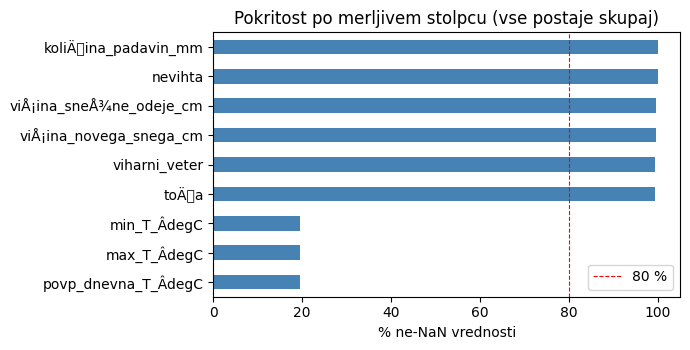

povp_dnevna_T_ÂdegC          19.5
max_T_ÂdegC                  19.5
min_T_ÂdegC                  19.5
toÄa                        99.4
viharni_veter                99.4
viÅ¡ina_novega_snega_cm      99.6
viÅ¡ina_sneÅ¾ne_odeje_cm     99.6
nevihta                     100.0
koliÄina_padavin_mm        100.0


In [6]:
# Delež ne-NaN vrednosti za vsak merilni stolpec
merilni_cols = [c for c in df.columns if c not in ("station_id", "datum", "leto")]
pokritost_col = df[merilni_cols].notna().mean().sort_values(ascending=True) * 100

fig, ax = plt.subplots(figsize=(7, max(3, len(merilni_cols) * 0.4)))
pokritost_col.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("% ne-NaN vrednosti")
ax.set_title("Pokritost po merljivem stolpcu (vse postaje skupaj)")
ax.axvline(80, color="red", linestyle="--", linewidth=0.8, label="80 %")
ax.legend()
plt.tight_layout()
plt.show()

print(pokritost_col.round(1).to_string())

## 5. Pregled konkretne postaje

In [ ]:
# Nastavi na ID postaje ki te zanima (ali None za interaktivni izbor spodaj)
POSTAJA_ID = 43  # npr. "43" ali "1808"

if POSTAJA_ID is 43:
    # Pokaži razpoložljive postaje
    razpolozljive = (
        df.groupby("station_id")["datum"]
        .agg(["min", "max", "count"])
        .rename(columns={"min": "od", "max": "do", "count": "n_dni"})
        .join(lokacije.set_index("station_id")[["ime", "tip"]], how="left")
        .sort_values("n_dni", ascending=False)
    )
    razpolozljive["od"] = razpolozljive["od"].dt.date
    razpolozljive["do"] = razpolozljive["do"].dt.date
    print("Nastavi POSTAJA_ID na enega od spodnjih ID-jev:")
    razpolozljive
else:
    razpolozljive = None

In [ ]:
if POSTAJA_ID is None:
    razpolozljive
else:
    df_p = df[df["station_id"] == str(POSTAJA_ID)].copy()
    ime = lokacije.set_index("station_id")["ime"].get(str(POSTAJA_ID), POSTAJA_ID)
    print(f"Postaja: {ime} (ID={POSTAJA_ID})")
    print(f"Vrstic: {len(df_p):,}  |  Obdobje: {df_p['datum'].min().date()} – {df_p['datum'].max().date()}")

    # Meritve po letu
    po_letu = df_p.groupby("leto").size().rename("n_dni")

    fig, ax = plt.subplots(figsize=(12, 3))
    po_letu.plot.bar(ax=ax, color="steelblue", width=0.85)
    ax.axhline(365, color="red", linestyle="--", linewidth=0.8, label="365 dni")
    ax.set_xlabel("Leto")
    ax.set_ylabel("Število dni")
    ax.set_title(f"Meritve po letu — {ime}")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Pokritost stolpcev za to postajo
    pokr = df_p[merilni_cols].notna().mean().sort_values(ascending=True) * 100
    print("\nPokritost stolpcev (%):\n", pokr.round(1).to_string())

    # Zadnjih 30 dni
    print("\nZadnjih 10 vrstic:")
    df_p.sort_values("datum").tail(10).to_string(index=False)